#### ***06 — Foundation Models: Google TimesFM vs Amazon Chronos***

We benchmarked four foundation models for time-series forecasting in zero-shot mode, **two per vendor** (base and large variants):

| Vendor | Model                       | Params | Architecture            |
|--------|-----------------------------|--------|-------------------------|
| Google | TimesFM 1.0                 | 200M   | Decoder-only, 20 layers |
| Google | TimesFM 2.0                 | 500M   | Decoder-only, 50 layers |
| Amazon | Chronos-T5 **base**         | 200M   | T5 encoder-decoder      |
| Amazon | Chronos-T5 **large**        | 710M   | T5 encoder-decoder      |

We kept the same rolling-origin protocol as the rest of the project (7-day horizon, 4 windows).

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import timesfm
from chronos import ChronosPipeline

from scripts.evaluation import rolling_origin_forecast, evaluate_windows, summarise

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

print(f'PyTorch {torch.__version__}   CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0].


PyTorch 2.11.0+cu128   CUDA: True
GPU: NVIDIA GeForce RTX 5070 Ti


#### ***Load processed data and split***

In [2]:
data = pd.read_csv('../data/processed_daily.csv', parse_dates=['date'], index_col='date')

TEST_DAYS = 30
HORIZON   = 7
SEASON    = 7

split_date = data.index.max() - pd.Timedelta(days=TEST_DAYS - 1)
train_y    = data.loc[data.index <  split_date, 'energy_kwh']
test_y     = data.loc[data.index >= split_date, 'energy_kwh']

print(f'Train: {len(train_y)} days   Test: {len(test_y)} days   Horizon: {HORIZON}   Windows: {len(test_y)//HORIZON}')

Train: 1897 days   Test: 30 days   Horizon: 7   Windows: 4


#### ***Google — TimesFM 1.0 (200M)***

Decoder-only architecture with 20 layers and positional embeddings. We left the context length at the default 512.

In [3]:
tfm_v1 = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend                  = 'gpu' if torch.cuda.is_available() else 'cpu',
        per_core_batch_size      = 32,
        horizon_len              = HORIZON,
        num_layers               = 20,
        use_positional_embedding = True,
        context_len              = 512,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(huggingface_repo_id='google/timesfm-1.0-200m-pytorch'),
)
print('TimesFM 1.0 (200M) loaded.')

def tfm_v1_fn(history, horizon):
    context = [history.values.astype(np.float32)]
    point, _ = tfm_v1.forecast(context, freq=[0])
    return point[0][:horizon]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

torch_model.ckpt:   0%|          | 0.00/814M [00:00<?, ?B/s]

TimesFM 1.0 (200M) loaded.


#### ***Google — TimesFM 2.0 (500M)***

50 layers, no positional embeddings, higher capacity.

In [4]:
tfm_v2 = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend                  = 'gpu' if torch.cuda.is_available() else 'cpu',
        per_core_batch_size      = 32,
        horizon_len              = HORIZON,
        num_layers               = 50,
        use_positional_embedding = False,
        context_len              = 192,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(huggingface_repo_id='google/timesfm-2.0-500m-pytorch'),
)
print('TimesFM 2.0 (500M) loaded.')

def tfm_v2_fn(history, horizon):
    context = [history.values.astype(np.float32)]
    point, _ = tfm_v2.forecast(context, freq=[0])
    return point[0][:horizon]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

TimesFM 2.0 (500M) loaded.


#### ***Amazon — Chronos-T5 base (200M)***

T5 encoder-decoder with quantisation-based tokenisation. The forecast is probabilistic via sampling — we took the median of 20 samples.

In [5]:
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
TORCH_DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
NUM_SAMPLES = 20

chronos_base = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-base',
    device_map = DEVICE,
    torch_dtype = TORCH_DTYPE,
)
print('Chronos-T5 base (200M) loaded.')

def chronos_base_fn(history, horizon):
    ctx = torch.tensor(history.values.astype(np.float32))
    forecast = chronos_base.predict(
        inputs=ctx, prediction_length=horizon, num_samples=NUM_SAMPLES,
    )
    # forecast shape: (1, num_samples, prediction_length)
    return np.median(forecast[0].cpu().numpy().astype(np.float32), axis=0)

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/806M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos-T5 base (200M) loaded.


#### ***Amazon — Chronos-T5 large (710M)***

In [6]:
chronos_large = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-large',
    device_map = DEVICE,
    torch_dtype = TORCH_DTYPE,
)
print('Chronos-T5 large (710M) loaded.')

def chronos_large_fn(history, horizon):
    ctx = torch.tensor(history.values.astype(np.float32))
    forecast = chronos_large.predict(
        inputs=ctx, prediction_length=horizon, num_samples=NUM_SAMPLES,
    )
    return np.median(forecast[0].cpu().numpy().astype(np.float32), axis=0)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos-T5 large (710M) loaded.


#### ***Rolling-origin evaluation***

Same protocol we have used in the previous notebooks — we call every model with the history up to each window and ask for a 7-day forecast.

In [7]:
def evaluate_model(name, fn):
    windows = rolling_origin_forecast(fn, train_y, test_y, horizon=HORIZON)
    per_window = evaluate_windows(windows, train_y, season=SEASON)
    summary = summarise(per_window)
    print(f'\n=== {name} ===')
    print(per_window.round(3).to_string(index=False))
    return windows, per_window, summary

results = {}
for name, fn in [
    ('TimesFM 1.0 (Google, 200M)',  tfm_v1_fn),
    ('TimesFM 2.0 (Google, 500M)',  tfm_v2_fn),
    ('Chronos-T5 base (Amazon, 200M)',  chronos_base_fn),
    ('Chronos-T5 large (Amazon, 710M)', chronos_large_fn),
]:
    w, pw, s = evaluate_model(name, fn)
    results[name] = {'windows': w, 'per_window': pw, 'summary': s}


=== TimesFM 1.0 (Google, 200M) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 15.447 18.271 0.422  0.337   3.606  0.056 0.391
      2 2023-11-07 20.329 21.257 0.639  0.477   9.954 -0.415 0.514
      3 2023-11-14 40.913 44.353 0.868  0.711 -24.080 -0.376 1.034
      4 2023-11-21 28.600 38.536 0.370  0.408 -16.975 -0.257 0.723



=== TimesFM 2.0 (Google, 500M) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 15.793 18.441 0.413  0.344   1.975  0.039 0.399
      2 2023-11-07 17.434 18.587 0.524  0.422   5.260 -0.082 0.441
      3 2023-11-14 43.058 47.451 0.836  0.753 -28.796 -0.575 1.089
      4 2023-11-21 28.631 38.683 0.367  0.408 -17.274 -0.266 0.724



=== Chronos-T5 base (Amazon, 200M) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 15.677 17.694 0.417  0.342   1.918  0.115 0.396
      2 2023-11-07 22.696 23.985 0.736  0.516  12.562 -0.801 0.574
      3 2023-11-14 42.335 46.901 0.875  0.733 -26.987 -0.538 1.070
      4 2023-11-21 28.527 42.430 0.319  0.401 -23.196 -0.524 0.721



=== Chronos-T5 large (Amazon, 710M) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 16.728 18.656 0.365  0.369  -6.276  0.016 0.423
      2 2023-11-07 19.410 20.517 0.572  0.461   5.937 -0.318 0.491
      3 2023-11-14 45.391 49.832 0.866  0.802 -31.494 -0.737 1.148
      4 2023-11-21 30.236 43.956 0.341  0.436 -25.217 -0.635 0.764


#### ***Google vs Amazon — comparison table***

We lined up all the standard project metrics, side by side.

In [8]:
def fmt_pm(s, m):   return f'{s[f"{m}_mean"]:.2f} ± {s[f"{m}_std"]:.2f}'
def fmt_pct(s, m):  return f'{s[f"{m}_mean"]*100:5.1f}% ± {s[f"{m}_std"]*100:4.1f}%'

table = pd.DataFrame({
    name: {
        'MAE':   fmt_pm(r['summary'], 'MAE'),
        'RMSE':  fmt_pm(r['summary'], 'RMSE'),
        'MAPE':  fmt_pct(r['summary'], 'MAPE'),
        'sMAPE': fmt_pct(r['summary'], 'sMAPE'),
        'MASE':  fmt_pm(r['summary'], 'MASE'),
        'Bias':  f'{r["summary"]["Bias_mean"]:+.2f}',
        'R²':    f'{r["summary"]["R2_mean"]:+.2f}',
    } for name, r in results.items()
}).T

table['_mase'] = [results[n]['summary']['MASE_mean'] for n in table.index]
table = table.sort_values('_mase').drop(columns='_mase')
table

,MAE,RMSE,MAPE,sMAPE,MASE,Bias,R²
"TimesFM 2.0 (Google, 500M)",26.23 ± 12.59,30.79 ± 14.62,53.5% ± 21.1%,48.2% ± 18.4%,0.66 ± 0.32,-9.71,-0.22
"TimesFM 1.0 (Google, 200M)",26.32 ± 11.14,30.60 ± 12.80,57.5% ± 22.8%,48.3% ± 16.2%,0.67 ± 0.28,-6.87,-0.25
"Chronos-T5 base (Amazon, 200M)",27.31 ± 11.31,32.75 ± 14.11,58.7% ± 26.2%,49.8% ± 17.2%,0.69 ± 0.29,-8.93,-0.44
"Chronos-T5 large (Amazon, 710M)",27.94 ± 13.02,33.24 ± 15.97,53.6% ± 24.3%,51.7% ± 19.4%,0.71 ± 0.33,-14.26,-0.42


#### ***Visualisations***

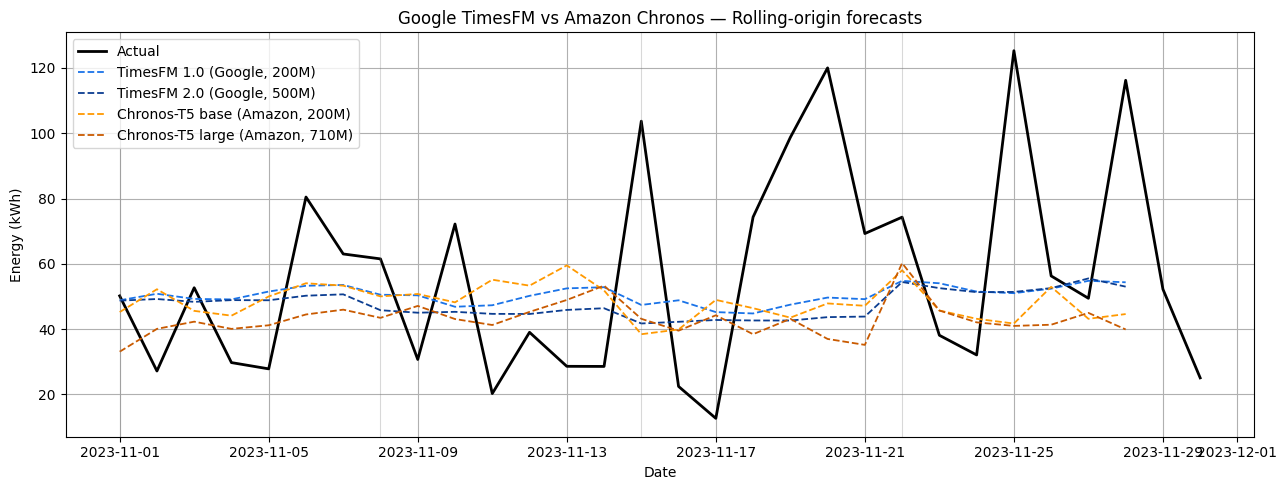

In [9]:
# Plot 1: forecast curves
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_y.index, test_y.values, 'k-', lw=2.0, label='Actual')

colors = {
    'TimesFM 1.0 (Google, 200M)':  '#1a73e8',
    'TimesFM 2.0 (Google, 500M)':  '#0b3d91',
    'Chronos-T5 base (Amazon, 200M)':  '#ff9900',
    'Chronos-T5 large (Amazon, 710M)': '#c95a00',
}
for name, r in results.items():
    idx   = np.concatenate([w['index'] for w in r['windows']])
    preds = np.concatenate([w['predictions'] for w in r['windows']])
    ax.plot(idx, preds, '--', color=colors[name], lw=1.3, label=name)

for w in next(iter(results.values()))['windows']:
    ax.axvline(w['index'][0], color='grey', alpha=0.3, lw=0.8)

ax.set_xlabel('Date'); ax.set_ylabel('Energy (kWh)')
ax.set_title('Google TimesFM vs Amazon Chronos — Rolling-origin forecasts')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

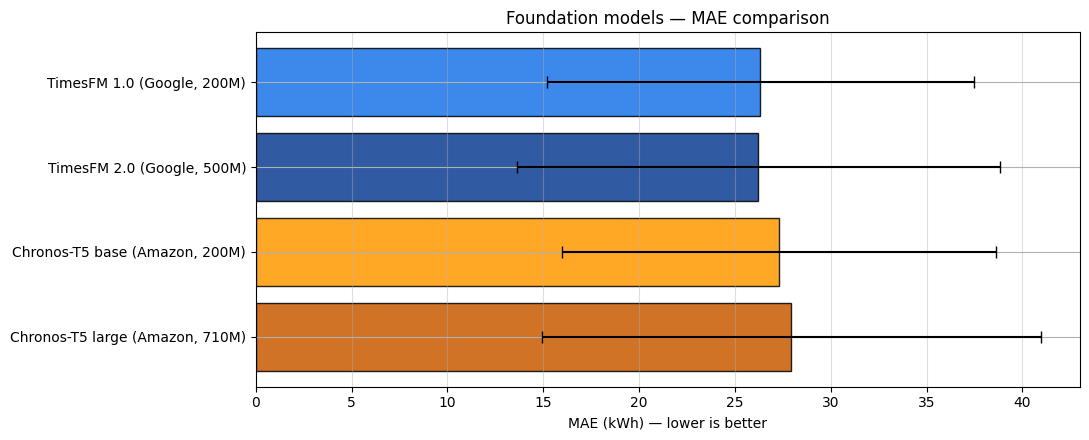

In [10]:
# Plot 2: MAE comparison with std
mae_means = pd.Series({n: r['summary']['MAE_mean'] for n, r in results.items()})
mae_stds  = pd.Series({n: r['summary']['MAE_std']  for n, r in results.items()})

fig, ax = plt.subplots(figsize=(11, 4.5))
bar_colors = [colors[n] for n in mae_means.index]
y_pos = np.arange(len(mae_means))
ax.barh(y_pos, mae_means.values, xerr=mae_stds.values, color=bar_colors,
        edgecolor='black', capsize=4, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(mae_means.index)
ax.invert_yaxis()
ax.set_xlabel('MAE (kWh) — lower is better')
ax.set_title('Foundation models — MAE comparison')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

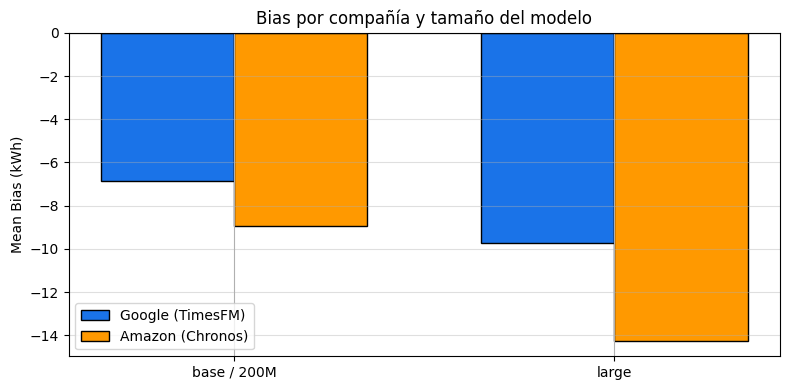

In [11]:
# Plot 3: bias per company
bias_data = {
    'Google (TimesFM)': [results['TimesFM 1.0 (Google, 200M)']['summary']['Bias_mean'],
                         results['TimesFM 2.0 (Google, 500M)']['summary']['Bias_mean']],
    'Amazon (Chronos)': [results['Chronos-T5 base (Amazon, 200M)']['summary']['Bias_mean'],
                         results['Chronos-T5 large (Amazon, 710M)']['summary']['Bias_mean']],
}
labels = ['base / 200M', 'large']

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, bias_data['Google (TimesFM)'], width, label='Google (TimesFM)', color='#1a73e8', edgecolor='black')
ax.bar(x + width/2, bias_data['Amazon (Chronos)'], width, label='Amazon (Chronos)', color='#ff9900', edgecolor='black')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean Bias (kWh)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Bias por compañía y tamaño del modelo')
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()